#Data Təmizləmə və Kəşfiyyat Analizi (EDA)

**Dataset:** Bakı daşınmaz əmlak satış elanları (Bina.az tipli struktur, ''sehriyarmemmedli/binaaz-sale-project'')



In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)


## 1) Data yükləmə və ilkin baxış


In [2]:
pip install kagglehub[pandas-datasets]

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub


# Load the latest version
path= kagglehub.dataset_download("sehriyarmemmedli/binaaz-sale-project")
print(path)

100%|██████████| 39.8M/39.8M [00:00<00:00, 89.3MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/sehriyarmemmedli/binaaz-sale-project/versions/1


In [4]:
import os
files = os.listdir(path)
print(files)


['house_sale.csv']


In [5]:

file_path = os.path.join(path, 'house_sale.csv')
df= pd.read_csv(file_path, low_memory=False)

In [6]:
df.shape

(100775, 51)

In [7]:
df.head(3)

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,...,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,...,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,...,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,...,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.


Checkpoint 1: forma, tiplər, boş dəyərlər, dublikatlar

In [9]:
df.dtypes

,0
id_x,object
rel_url,object
estate_rel_url_x,object
datetime_scrape_x,object
price,float64
currency_x,object
location,object
attributes,object
city_when,object
city,object


In [10]:
df.head(1)

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,...,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,...,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.


In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
Binanın növü,100621
featured,97626
vip,92179
Torpaq sahəsi,85204
hour_y,85144
İpoteka,67836
mortgage,67836
shop_title,28757
shop_name,28757
products_label,28145


In [12]:
(df.isnull().mean() * 100).round(2).sort_values(ascending=False)

,0
Binanın növü,99.85
featured,96.88
vip,91.47
Torpaq sahəsi,84.55
hour_y,84.49
İpoteka,67.31
mortgage,67.31
shop_title,28.54
shop_name,28.54
products_label,27.93


### Null strategiyası: ümumi çərçivə

Aşağıdakı doldurma qərarları sütunun mənasına görə dörd qrupa bölünüb — tək bir üsul (məs. mode) bütün sütunlara mexaniki tətbiq olunmur. Hər qrupun öz məntiqi var, və hər sütun üçün ayrıca, niyə məhz bu üsul seçildiyi izah olunur:

1. Strukturlaşdırılmış yoxluq (featured, vip, mortgage, İpoteka, bill_of_sale) — bu sütunlarda NaN 'məlumat itib' demək deyil, sözün əsl mənasında 'bu əlamət yoxdur' deməkdir (elan VIP kimi işarələnməyibsə, sahə sadəcə boş qalır). Ona görə mode və ya median deyil, mənanı əks etdirən sabit dəyər ilə doldurulur.
2. Aşağı-null-faizli, kəskin bölgülü kateqorik/ordinal sütunlar (products_label, unit_price, Mərtəbə, Otaq sayı, Təmir, owner_title) — hər birinin null payı 1%-dən aşağıdır və bölgü bir neçə dəyər ətrafında kəskin cəmləşib, ona görə sütunun öz mode dəyəri ilə doldurulması real bölgünü təhrif etmir. Amma mode-un niyə uyğun olduğu hər sütun üçün ayrıca əsaslandırılır aşağıda.
3. Redundant / yüksək-kardinallıqlı identifikator sütunlar (Binanın növü, shop_name, shop_title, owner_name) — bunlar 2-ci bölmədə (cols_to_drop) redundant və ya sərbəst-mətn identifikator kimi artıq silinəcək. Bu sütunları mode ilə doldurmaq (məs. minlərlə fərqli elana eyni 'ən çox rast gəlinən' sahib/agent adını yapışdırmaq) real dəyəri olmayan, uydurma məlumat yaradardı əvəzinə doldurmadan saxlanılır və birbaşa silinir.
4. Çox yüksək null faizli və ya açıq-aşkar redundant sütunlar (Torpaq sahəsi, hour_y, repair) — doldurmaq mənasızdır (60-70%-dən çox boşluğu hər hansı dəyərlə doldurmaq süni siqnal yaradar, ya da sütun onsuz da başqa sütunun dublikatıdır), ona görə birbaşa silinir.


**featured** — NaN burada ölçmə xətası deyil: elan featured (önə çıxarılmış) kimi işarələnməyibsə sahə sadəcə boş qalır. Buna görə mode/median deyil, mənanı əks etdirən sabit dəyərlə (not featured) doldururuq.

In [13]:
df['featured'].sort_values()

,featured
0,featured
44710,featured
44785,featured
44884,featured
45241,featured
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


In [14]:
# NaN dəyərləri 'not featured' olaraq dolduraq
df['featured'] = df['featured'].fillna('not featured')

**vip** — eyni məntiq: NaN = elan VIP paketi ilə yerləşdirilməyib, sabit dəyərlə doldurulur.

In [15]:
df['vip'].sort_values()

,vip
0,vipped
46699,vipped
46653,vipped
46595,vipped
46591,vipped
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


In [16]:
# NaN dəyərləri 'not vipped' olaraq doldurmaq
df['vip'] = df['vip'].fillna('not vipped')

**mortgage** və **İpoteka** — hər ikisi strukturlaşdırılmış yoxluqdur (NaN = ipoteka seçimi göstərilməyib). Üstəlik bu iki sütun aşağıda (Checkpoint-in sonunda) bir-biri ilə **uzlaşma yoxlamasında** (mortgage ~ İpoteka) istifadə olunacaq, ona görə silinmədən əvvəl mütləq doldurulmalıdırlar — yoxlama NaN üzərində mənasız nəticə verərdi.

In [17]:
df['mortgage'].value_counts()

,count
mortgage,
İpoteka var,32939


In [18]:
# NaN dəyərləri 'Ipoteka yoxdur' olaraq doldurmaq
df['mortgage'] = df['mortgage'].fillna('Ipoteka yoxdur')

In [19]:
df['İpoteka'].value_counts()

,count
İpoteka,
var,32939


In [20]:
# NaN dəyərləri 'yox' olaraq doldurmaq
df['İpoteka'] = df['İpoteka'].fillna('yox')

**bill_of_sale** — eyni səbəbdən doldurulur: aşağıda Çıxarış sütunu ilə uzlaşma yoxlamasında istifadə olunacaq (bill_of_sale ~ Çıxarış).

In [22]:
df['bill_of_sale'].value_counts()

,count
bill_of_sale,
Çıxarış var,79565


In [24]:
df['bill_of_sale']=df['bill_of_sale'].fillna('Cixaris yoxdur')

**Aşağı-null-faizli kateqorik/ordinal sütunlar** — hər biri üçün mode seçiminin öz əsaslandırması var, sadəcə təkrarlanan qərar deyil:

In [25]:
df['products_label'].value_counts()

,count
products_label,
Agentlik,71981
Kompleks,649


products_label: məhdud sayda diskret paket növünə (dəyərinə) malikdir; null payı çox aşağıdır. Mode ilə doldurmaq bölgünü praktik olaraq dəyişmir, çünki əksəriyyət onsuz da eyni paketdədir.

In [26]:
df['products_label']=df['products_label'].fillna(df['products_label'].mode()[0])

In [27]:
df['unit_price'].value_counts()

,count
unit_price,
2 500 AZN/m²,1192
2 000 AZN/m²,1061
2 330 AZN/m²,749
2 200 AZN/m²,724
3 000 AZN/m²,679
...,...
702 AZN/m²,1
811 AZN/m²,1
948 AZN/m²,1


unit_price: mətn şəklində saxlanılsa da (məs. '3 450 AZN/m²'), dəyərlər diskret qiymət etiketləri kimi təkrarlanır — median hesablamaq mətn üzərində mənasızdır, mode isə real bazarda ən tez-tez rast gəlinən kəsimi əks etdirir.

In [28]:
df['unit_price']=df['unit_price'].fillna(df['unit_price'].mode()[0])

In [29]:
df['Mərtəbə'].value_counts()

,count
Mərtəbə,
5 / 5,1989
3 / 5,1764
2 / 5,1761
4 / 5,1680
8 / 9,1369
...,...
10 / 25,1
22 / 26,1
12 / 30,1


Mərtəbə: 'mərtəbə / ümumi mərtəbə' formatında mətndir (məs. '3/9') — nisbət formatında olduğu üçün median mənasızdır. Ən tez-tez rast gəlinən kombinasiya etibarlı defolt təşkil edir.

In [30]:
df['Mərtəbə']=df['Mərtəbə'].fillna(df['Mərtəbə'].mode()[0])

In [31]:
df['Otaq sayı'].value_counts()

,count
Otaq sayı,
3.0,36191
2.0,27435
4.0,15673
5.0,4850
1.0,2618
6.0,2306
7.0,978
8.0,582
10.0,247


Otaq sayı: diskret, dar diapazonlu (adətən 1-6) ordinal dəyişəndir. Bölgü kəskin şəkildə 2-3 otaq ətrafında cəmləşdiyi üçün bu halda mode və median praktik olaraq eyni nəticəni verir; sadəlik naminə mode seçilib.

In [32]:
df['Otaq sayı']=df['Otaq sayı'].fillna(df['Otaq sayı'].mode()[0])

In [33]:
df['Təmir'].value_counts()

,count
Təmir,
var,81612
yoxdur,13162


Təmir: binar-yaxın kateqorik dəyişəndir (var/yoxdur). Əksər elanlar bu vəziyyəti aydın bildirdiyi üçün mode konservativ və etibarlı defolt seçimdir.

In [35]:
df['Təmir']=df['Təmir'].fillna(df['Təmir'].mode()[0])

owner_title (sahib / vasitəçi-agent): yalnız bir neçə diskret dəyərə malikdir və aşağıda 'Yazılı nəticə' bölməsində agent payı hesablanarkən istifadə olunacaq — buna görə saxlanılır və mode ilə doldurulur (identifikator deyil, kateqoriyadır, ona görə 3-cü qrupdan fərqli rəftar edilir).

In [36]:
df['owner_title']=df['owner_title'].fillna(df['owner_title'].mode()[0])

**Redundant / identifikator sütunlar — qəsdən doldurulmur.** Binanın növü, shop_name, shop_title və owner_name aşağıda (2-ci bölmə, cols_to_drop) redundant və ya yüksək-kardinallıqlı sərbəst-mətn identifikator kimi silinəcək. shop_name və owner_name minlərlə fərqli mağaza/sahib adını ehtiva edir mode ilə doldursaq, ən tez-tez rast gəlinən BİR adı bütün digər elanlara süni şəkildə yapışdırmış olardıq, bu, real dəyəri olmayan uydurma məlumat yaradar. Ona görə bu dördü mode ilə doldurmuruq (əvvəlki notebook versiyasında bu, əsassız/mexaniki addım idi) sadəcə inspeksiya edib NaN halında saxlayır, bir neçə addım sonra sütunla birlikdə silirik.

In [37]:
df['Binanın növü'].sort_values()

,Binanın növü
52542,Biznes mərkəzi
61022,Biznes mərkəzi
60693,Biznes mərkəzi
59215,Biznes mərkəzi
58625,Biznes mərkəzi
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


In [39]:
df['shop_name'].value_counts()

,count
shop_name,
Real Əmlak Yeni Yasamal,2482
"EVA Group ""Röyal Əmlak""",1936
Real Əmlak Nərimanov,1514
My Dom,1470
"EVA Group ""Platin Real Estate""",1376
...,...
Al Əmlak,1
House Club,1
F&M Club,1


In [40]:
df['shop_title'].value_counts()

,count
shop_title,
Daşınmaz əmlak agentliyi,72018


In [41]:
df['owner_name'].value_counts()

,count
owner_name,
Elan sahibi,1618
Rauf,1136
Samir,1050
Real Əmlak,895
Murad,890
...,...
islam,1
Xalqa Xidmet,1
Orxan M.,1


In [42]:
df['Torpaq sahəsi'].sort_values()

,Torpaq sahəsi
62482,0.1 sot
90016,0.1 sot
50945,0.1 sot
80348,0.1 sot
34608,0.1 sot
...,...
100767,NaN
100768,NaN
100769,NaN
100773,NaN


Torpaq sahəsi: null payı 60-70%-dən yuxarıdır (yuxarıdakı faiz cədvəlinə bax). Bu qədər boşluğu hər hansı üsulla doldurmaq süni siqnal yaradardı sütun birbaşa silinir.

In [43]:
df.drop('Torpaq sahəsi', axis=1, inplace=True)

In [44]:
df['hour_y'].sort_values()

,hour_y
8849,00:00
8848,00:02
14171,00:03
25835,00:03
25836,00:03
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


hour_y: dəyərləri hour_x sütunu ilə üst-üstə düşür — dublikat sütundur, əlavə məlumat vermir, doldurmadan silinir.



In [45]:
df.drop('hour_y', axis=1, inplace=True)

In [46]:
df['repair'].value_counts()

,count
repair,
Təmirli,81612


repair: Təmir sütunu ilə demək olar ki eyni məlumatı daşıyır (dəyər dəstləri üst-üstə düşür) redundant sütun, doldurulmadan silinir.

In [47]:
#Temir columnu var deye buna ehtiyac qalmir ve silirik
df.drop('repair', axis=1, inplace=True)

**description** (sətir səviyyəsində silmə): null sayı digər sütunlarla müqayisədə çox kiçikdir (aşağıdakı final null-yoxlamasına bax). Sərbəst mətni hər hansı bir dəyərlə (boş sətir, mode və s.) doldurmaq süni/mənasız mətn yaradardı, ona görə əvəzinə bu az sayda sətir silinir.

In [48]:
df.dropna(subset=['description'], inplace=True)

In [49]:
df.isnull().sum().sort_values(ascending=False)

,0
Binanın növü,100356
shop_name,28539
shop_title,28539
owner_name,647
id_x,0
rel_url,0
estate_rel_url_x,0
datetime_scrape_x,0
city_when,0
city,0


In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.head(4)

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,vipped,featured,Agentlik,Çıxarış var,Ipoteka yoxdur,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,var,var,yox,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,not vipped,not featured,Agentlik,Cixaris yoxdur,Ipoteka yoxdur,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",2 500 AZN/m²,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,5 / 5,4.0,90 m²,var,yoxdur,yox,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,not vipped,not featured,Agentlik,Çıxarış var,Ipoteka yoxdur,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,2 500 AZN/m²,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,5 / 5,3.0,60 m²,var,var,yox,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,vipped,featured,Agentlik,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,2 500 AZN/m²,95000.0,AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,5 / 5,3.0,130 m²,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.


İlkin müşahidə: Sətir səviyyəsində nə tam dublikat, nə də estate_id üzrə təkrar var — hər sətir unikal bir elandır. Lakin bu, datanın təmiz olduğu demək deyil:

- Bir çox ədədi göstərici mətn kimi saxlanılıb (Sahə: "145 m²", Mərtəbə: "7 / 9", unit_price: 3 450 AZN/m²") — analiz üçün parse edilməlidir.
- Sütunlar arasında açıq redundantlıq var (eyni məlumat bir neçə dəfə fərqli adla): aşağıda yoxlanılıb.
- price ilə total_price demək olar ki, eynidir — biri artıqdır.
- Sahe sütunu iki fərqli ölçü vahidini (m² və torpaq üçün sot) qarışdırır — bunları birbaşa müqayisə etmək məntiqsizdir.

Qeyd: Binanın növü, shop_name, shop_title, owner_name bu addımda hələ də null göstərə bilər — bu gözlənilir, çünki bu dörd sütun bir neçə sətir aşağıda (cols_to_drop) birbaşa silinir (yuxarıya bax, niyə doldurulmadıqları izah olunub).

In [52]:
checks = {
    "id_x == estate_id": (df["id_x"] == df["estate_id"]).mean(),
    "estate_rel_url_x == estate_rel_url_y": (df["estate_rel_url_x"] == df["estate_rel_url_y"]).mean(),
    "estate_rel_url_x == estate_rel_url": (df["estate_rel_url_x"] == df["estate_rel_url"]).mean(),
    "estate_details_id_x == estate_details_id_y": (df["estate_details_id_x"] == df["estate_details_id_y"]).mean(),
    "price == total_price": (df["price"] == df["total_price"]).mean(),
    "bill_of_sale ~ Çıxarış": (df["bill_of_sale"].str.contains("var") == (df["Çıxarış"] == "var")).mean(),
    "mortgage ~ İpoteka": (df["mortgage"].str.contains("var") == (df["İpoteka"] == "var")).mean(),
    "currency_x == currency_y == 'AZN' (unikal say)": df["currency_x"].nunique(),}

In [53]:
for k, v in checks.items():
    print(f"{k}: {v}")

id_x == estate_id: 1.0
estate_rel_url_x == estate_rel_url_y: 1.0
estate_rel_url_x == estate_rel_url: 1.0
estate_details_id_x == estate_details_id_y: 1.0
price == total_price: 0.9998706596358571
bill_of_sale ~ Çıxarış: 1.0
mortgage ~ İpoteka: 1.0
currency_x == currency_y == 'AZN' (unikal say): 1


bele cixir ki eynidiler 1.0

In [54]:
cols_to_drop = [
    "id_x", "estate_rel_url_x", "estate_rel_url_y", "estate_rel_url",
    "estate_details_id_x", "estate_details_id_y", "total_price",
    "datetime_scrape_x", "datetime_scrape_y", "city_when", "hour_x", "day_y", "updated",
    "img_url", "description", "attributes", "extra_info", "owner_name",
    "shop_name", "shop_title", "bill_of_sale", "mortgage", "currency_x", "currency_y",
    "id_y", "rel_url", "Binanın növü", "address",]
df= df.drop(columns=cols_to_drop).rename(columns={"day_x": "elan_tarixi"})

In [55]:
df.columns

Index(['price', 'location', 'city', 'elan_tarixi', 'vip', 'featured',
       'products_label', 'estate_id', 'unit_price', 'owner_title', 'lat',
       'lng', 'views', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı', 'Sahə', 'Təmir',
       'Çıxarış', 'İpoteka'],
      dtype='object')

In [56]:
df.shape

(100510, 20)

Artiq elimizde real ve tamamile temiz dublikatsiz dolu ,muxtelif yanasmalarla doldurulmus data var

## 2) Sütun üzrə əsaslandırılmış təmizləmə strategiyasi

In [57]:
df.head(2)

,price,location,city,elan_tarixi,vip,featured,products_label,estate_id,unit_price,owner_title,lat,lng,views,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Təmir,Çıxarış,İpoteka
0,499999.0,Səbail r.,bakı,05.10.2024,vipped,featured,Agentlik,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,3 450 AZN/m²,mülkiyyətçi,40.358817,49.824092,1155,Köhnə tikili,7 / 9,4.0,145 m²,var,var,yox
1,77000.0,Biləcəri q.,bakı,05.10.2024,not vipped,not featured,Agentlik,883e20f0-8872-49a5-8b4b-63b8301b5f8f,2 500 AZN/m²,vasitəçi (agent),40.420897,49.807035,218,Həyət evi/Bağ evi,5 / 5,4.0,90 m²,var,yoxdur,yox


**Sahə** mətn sütunu iki fərqli ölçünü ('145 m²' və ya '6 sot') eyni sətirdə qarışdırır. Ədədi hissəni vahiddən ayırırıq ki, m² ilə sot birbaşa müqayisə edilməsin (aşağıda 3-cü bölmədə bu ayrımdan istifadə olunacaq).

In [59]:
# Sahə: ədəd + vahid ayırılması
sahe = df["Sahə"].str.extract(r"([\d.]+)\s*(m²|sot)")
df["sahe_deyeri"] = sahe[0].astype(float)
df["sahe_vahidi"] = sahe[1]

In [60]:
df.drop("Sahə", axis=1, inplace=True)

In [61]:
'''sahe_vahidi == "sot" olan sətirlər (Torpaq` kateqoriyası, torpaq sahəsi ölçü vahidi — 1 sot ≈ 100 m²) qalan m2-lə ölçülən əmlaklardan ayrıca təhlil olunmalıdır,
 əks halda orta sahə kimi göstəricilər mənasız qarışıq nəticə verər'''

'sahe_vahidi == "sot" olan sətirlər (Torpaq` kateqoriyası, torpaq sahəsi ölçü vahidi — 1 sot ≈ 100 m²) qalan m2-lə ölçülən əmlaklardan ayrıca təhlil olunmalıdır,\n əks halda orta sahə kimi göstəricilər mənasız qarışıq nəticə verər'

**Mərtəbə** ('mərtəbə/ümumi mərtəbə' formatında mətn) eyni məntiqlə iki ayrı ədədi sütuna ('mertebe', 'umumi_mertebe') parçalanır bu, aşağıda 'mərtəbə nisbəti' feature-ı üçün lazımdır.

In [62]:
# Mərtəbə: mertebe / umumi_mertebe
mertebe = df["Mərtəbə"].str.extract(r"(\d+)\s*/\s*(\d+)")
df["mertebe"] = mertebe[0].astype(int)
df["umumi_mertebe"] = mertebe[1].astype(int)

In [63]:
df.drop("Mərtəbə", axis=1, inplace=True)

**unit_price** mətn daxilindəki boşluqları (rəqəm ayırıcısı kimi işlədilib, məs. '3 450') silərək ədədə çeviririk.

In [64]:
# unit_price: ədədi çevrilmə (boşluqları rəqəm ayırıcısı kimi silmək)
df["elan_qiymeti_m2"] = (df["unit_price"].str.replace(r"[^\d]", "", regex=True).astype(float))
df.drop("unit_price", axis=1, inplace=True)

**city** və **location** sütunlarında ətraf boşluqlar (' Bakı ' kimi) mövcuddur — bunlar .strip() edilməzsə eyni şəhər fərqli kateqoriya kimi qruplaşdırıla bilər.

In [66]:
df["city"] = df["city"].str.strip()
df["location"] = df["location"].str.strip()


In [67]:
df.head(2)

,price,location,city,elan_tarixi,vip,featured,products_label,estate_id,owner_title,lat,lng,views,Kateqoriya,Otaq sayı,Təmir,Çıxarış,İpoteka,sahe_deyeri,sahe_vahidi,mertebe,umumi_mertebe,elan_qiymeti_m2
0,499999.0,Səbail r.,bakı,05.10.2024,vipped,featured,Agentlik,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,mülkiyyətçi,40.358817,49.824092,1155,Köhnə tikili,4.0,var,var,yox,145.0,m²,7,9,3450.0
1,77000.0,Biləcəri q.,bakı,05.10.2024,not vipped,not featured,Agentlik,883e20f0-8872-49a5-8b4b-63b8301b5f8f,vasitəçi (agent),40.420897,49.807035,218,Həyət evi/Bağ evi,4.0,var,yoxdur,yox,90.0,m²,5,5,2500.0


##3) Outlier (kənar dəyər) aşkarlanması və emalı

**Vacib metodoloji qərar:** price və sahe_deyeri bölgüsü Kateqoriyadan (Yeni tikili, Torpaq, Obyekt və s.) asılı olaraq **tamamilə fərqli miqyaslardadır** məs. Torpaq elanları milyonlarla AZN ola bilər, Qaraj isə on minlərlə. Ona görə IQR sərhədləri bütün dataset üzrə deyil, hər Kateqoriya daxilində ayrıca hesablanır — əks halda qlobal IQR ya Torpaq elanlarının hamısını outlier sayardı, ya da real qiymət xətalarını gizlədərdi.

In [69]:
df.groupby("Kateqoriya")["price"].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
Kateqoriya,,,,,,,,
Həyət evi/Bağ evi,15502.0,350381.0,455437.0,127.0,115000.0,235000.0,420000.0,12000000.0
Köhnə tikili,18058.0,166071.0,108068.0,700.0,120000.0,145000.0,185000.0,3400000.0
Obyekt,4034.0,1247083.0,2172922.0,11.0,250000.0,593000.0,1350000.0,36000000.0
Ofis,154.0,773707.0,807793.0,32000.0,295000.0,475000.0,1100000.0,5780000.0
Qaraj,89.0,51889.0,156464.0,8500.0,20000.0,30000.0,45000.0,1500000.0
Torpaq,4892.0,751885.0,2361484.0,800.0,49000.0,150000.0,392750.0,40000000.0
Yeni tikili,57781.0,286989.0,324980.0,73.0,175000.0,245000.0,340000.0,60000000.0


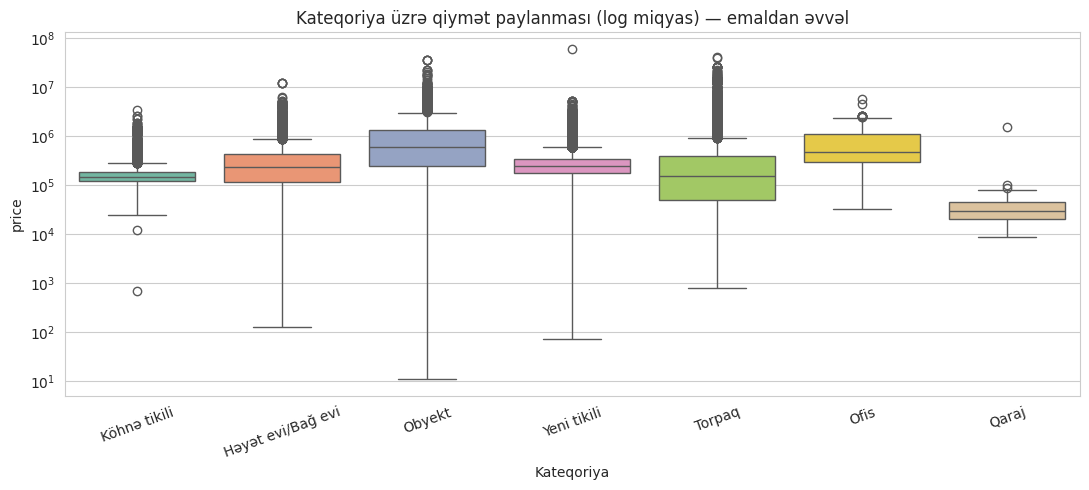

In [70]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="Kateqoriya", y="price", ax=ax, palette="Set2")
ax.set_yscale("log")
ax.set_title("Kateqoriya üzrə qiymət paylanması (log miqyas) — emaldan əvvəl")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [71]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return max(q1 - 1.5 * iqr, 0), q3 + 1.5 * iqr


In [72]:
df.shape

(100510, 22)

In [73]:
#Açıq-aşkar məntiqsiz dəyərlər real bazarda mümkün olmayan
# ifrat aşağı qiymətlər bir neçə AZN "mənzil ola bilməz)
df = df[df["price"] >= 500]

In [74]:
#Hər Kateqoriya daxilində ayrıca IQR əsaslı capping silmək əvəzinə kəsmə
# ki seqmentin ölçüsü və nisbətləri qorunsun
def cap_by_group(frame, value_col, group_col):
    frame = frame.copy()
    for g, idx in frame.groupby(group_col).groups.items():
        lo, hi = iqr_bounds(frame.loc[idx, value_col])
        frame.loc[idx, value_col] = frame.loc[idx, value_col].clip(lo, hi)
    return frame

In [75]:
df = cap_by_group(df, "price", "Kateqoriya")

In [76]:
#sahe_deyeri üçün də eyni məntiq, amma vahidə görə ayrıca m2 vs sot qarışmasın
df = cap_by_group(df, "sahe_deyeri", "sahe_vahidi")

In [77]:
#views sütununda ifrat kənar dəyərlər
lo_v, hi_v = iqr_bounds(df["views"])
df["views"] = df["views"].clip(lo_v, hi_v)

In [78]:
df.shape

(100504, 22)

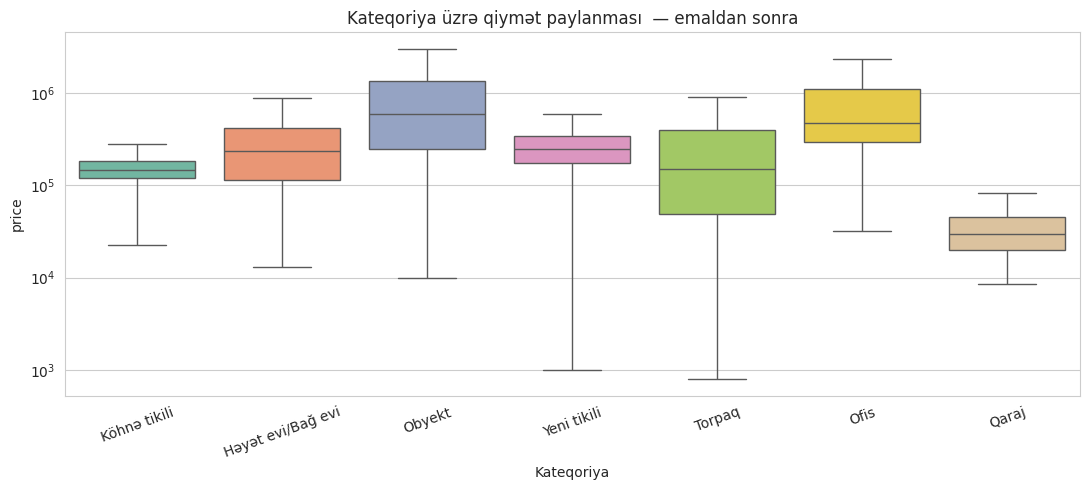

In [79]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="Kateqoriya", y="price", ax=ax, palette="Set2")
ax.set_yscale("log")
ax.set_title("Kateqoriya üzrə qiymət paylanması  — emaldan sonra")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Qərarın əsaslandırılması:** Sətirlər kütləvi silinmədi — yalnız açıq-aşkar məntiqsiz qiymətlər (500 AZNdən aşağı — real bazarda mümkün deyil) çıxarıldı. Qalan ifrat dəyərlər isə hər kateqoriya daxilində ayrıca IQR sərhədlərinə **kəsildi (capped)** silinmədi bu həm ekstremal təhrifi aradan qaldırır, həm də kateqoriyalar arası nisbətləri və sətir sayını qoruyur.

**Data sızması (leakage):** views (baxış sayı) sütunu elanın artıq bazarda olduğu müddət ərzində toplanmış kumulyativ göstəricidir. Əgər gələcəkdə bu elan nə qədər müddətə satılacaq tipli proqnoz modeli qurulsaydı, views-dan istifadə etmək data leakage olardı, çünki bu, nəticənin satışın özü baş vermədən əvvəl real vaxtda mövcud olmayan, yalnız retrospektiv toplanan məlumatdır. Bu EDA da sütun analitik məqsədlə saxlanılıb, lakin proqnozlaşdırma tapşırığında ehtiyatla istifadə olunmalıdır.

## 4) Feature Engineering

**Qeyd (sıra dəyişikliyi — bug fix):** Əvvəlki versiyada sot→m² çevrilməsi kvadratmetr qiymətinin hesablanmasından *sonra* aparılırdı. Nəticədə qiymet_m2_hesablanmis yalnız sahe_vahidi == 'm²' olan sətirlər üçün hesablanırdı, Torpaq (sot ilə ölçülən) elanlarının hamısı NaN qalırdı. Bu, aşağıdakı 'Yazılı nəticə' bölməsində **'Torpaq: nan AZN/m²'** xətasına səbəb olurdu — sətirlər üzrə NaN uncritically çap edilirdi. Düzəliş: əvvəlcə bütün sahələri m²-ə çeviririk (sot dəyərini ×100 ilə), sonra AZN/m² göstəricisini bütün kateqoriyalar üçün eyni şəkildə hesablayırıq.

In [80]:
df["sahe_vahidi"] = df["sahe_vahidi"].astype(str).str.lower().str.strip()

# Sot -> m² çevrilməsi ARTIQ BURADA, feature hesablanmazdan əvvəl aparılır (bug fix:
# əvvəllər bu addım aşağıda idi və Torpaq elanları qiymet_m2_hesablanmis-də NaN qalırdı)
df.loc[df["sahe_vahidi"] == "sot", "sahe_deyeri"] = (
    df.loc[df["sahe_vahidi"] == "sot", "sahe_deyeri"] * 100
)


**qiymet_m2_hesablanmis** (AZN/m²): xam price fərqli ölçülü əmlakları (stüdiya vs villa, mənzil vs torpaq sahəsi) birbaşa müqayisə etməyə imkan vermir. Qiyməti sahəyə bölmək bütün kateqoriyaları **ümumi bir şkalaya** gətirir bu, həm modelin ölçüdən asılı olmayan siqnalı öyrənməsinə kömək edir, həm də aşağıdakı 'ən baha/ucuz kateqoriya' müqayisəsinin əsasını təşkil edir. İndi vahid çevrilməsi əvvəlcədən aparıldığı üçün np.where ilə yalnız m²-ə məhdudlaşdırmağa ehtiyac qalmır — bütün sətirlər üçün hesablanır.

In [81]:
df["qiymet_m2_hesablanmis"] = df["price"] / df["sahe_deyeri"]


**mertebe_nisbeti** (mərtəbə / ümumi mərtəbə): mütləq mərtəbə nömrəsi (məs. 5-ci mərtəbə) binanın hündürlüyündən asılı olaraq fərqli məna daşıyır (9 mərtəbəli binada 5-ci mərtəbə orta, 24 mərtəbəlidə isə aşağı hesab olunur). Nisbi mövqe modelə **müqayisə edilə bilən** bir siqnal verir binanın hündürlüyündən asılı olmayaraq.

In [82]:
#Mərtəbə nisbəti — mənzilin binada nisbi mövqeyi
df["mertebe_nisbeti"] = df["mertebe"] / df["umumi_mertebe"]

**teshvigatli_elan** (VIP və ya featured): iki ayrı bayraq sütununu (vip, featured) tək binar dəyişəndə birləşdirir. Elanın 'təşviq edilib-edilməməsi' həm görünürlük, həm də satıcının elana nə qədər investisiya qoyduğunun proksi göstəricisi ola bilər analiz və gələcək modelləşdirmə üçün iki ayrı korrelyasiyalı sütun yerinə bir yığcam feature daha sadədir.

In [83]:
#VIP/featured elan olub-olmaması bir bayraqda (təşviqatlı elan)
df["teshvigatli_elan"] = (
    (df["vip"] == "vipped") | (df["featured"] == "featured")).astype(int)

**sened_hazir_ipotekali**: Çıxarışı olan VƏ ipoteka mümkün olan elanları bir indeksdə birləşdirir. Bu iki şərt real bazarda birgə alıcı üçün 'sənəd baxımından hazır' əmlakı müəyyən edir bu tip birgə şərt bir modeldə iki ayrı binar sütun kimi deyil, mənalı kombinasiya kimi daha güclü siqnal daşıya bilər.

In [84]:
#Sənəd hazırlığı indeksi: çıxarışı olan VƏ ipoteka mümkün olan elanlar
df["sened_hazir_ipotekali"] = (
    (df["Çıxarış"] == "var") & (df["İpoteka"] == "var")).astype(int)

**elanin_yasi_gun** (Days on Market): elanın neçə gündür bazarda olduğunu göstərir bu, həm tələb-təklif dinamikasının, həm də qiymətin bazar reallığına uyğunluğunun (uzun müddət satılmayan elan çox güman ki yüksək qiymətlidir) proksisidir. Ən son tarix 'bu gün' kimi qəbul edilir ki, bütün keçmiş elanlar üçün ardıcıl və müqayisə edilə bilən yaş hesablansın.

In [85]:
#Elanın yaşı Days on Market
#Tarix sütununu pandas datetime formatına çeviririk
df['elan_tarixi'] = pd.to_datetime(df['elan_tarixi'], format='%d.%m.%Y')

In [86]:
# Model üçün ən məntiqlisi datasetdəki ən son tarixi bu gün kimi qəbul etməkdir,
# beləcə keçmiş məlumatlar üçün də doğru yaş hesablanır.
son_tarix = df['elan_tarixi'].max()

In [87]:
df['elanin_yasi_gun'] = (son_tarix - df['elan_tarixi']).dt.days

sahe_vahidi sütunu artıq lazım deyil bütün dəyərlər yuxarıda m²-ə çevrildi, ona görə sütunu silirik (əvvəlki versiyada bu addım feature hesablamasından sonra idi, indi əvvəldə aparıldığı üçün burada yalnız təmizlik qalır).

In [88]:
df = df.drop(columns=["sahe_vahidi"])


**Binar kodlaşdırma** (Təmir, Çıxarış, İpoteka): mətn kateqoriyalarını (var/yox) 0/1-ə çeviririk. Bu, həm xətti modellərin (Linear Regression) əmsal kimi birbaşa istifadə edə bilməsi, həm də ağac əsaslı alqoritmlərin (XGBoost, Random Forest) bölünmə (split) qərarlarını sadələşdirməsi üçün lazımdır mətn kateqoriyaları bu modellərin heç biri üçün birbaşa faydalı deyil.

In [89]:
# Binar Kodlaşdırma (Təmir, Çıxarış, İpoteka)
binar_sutunlar = ['Təmir', 'Çıxarış', 'İpoteka']

for col in binar_sutunlar:
    df[col] = df[col].astype(str).str.lower().str.strip()
# map edirik
    df[col] = df[col].map({
        'var': 1,
        'yox': 0,
        'yoxdur': 0})

In [90]:
df[['elan_tarixi', 'elanin_yasi_gun', 'sahe_deyeri', 'Təmir', 'Çıxarış', 'İpoteka']].head()

,elan_tarixi,elanin_yasi_gun,sahe_deyeri,Təmir,Çıxarış,İpoteka
0,2024-10-05,45,145.0,1,1,0
1,2024-10-05,45,90.0,1,0,0
2,2024-10-05,45,60.0,1,1,0
3,2024-10-05,45,130.0,1,1,1
4,2024-10-05,45,100.0,1,1,0


Bu dəyişikliklər həm xətti modellər (Linear Regression), həm də ağac əsaslı alqoritmlər (XGBoost, Random Forest, LightGBM) üçün daha dolğun məlumat təmin edəcək.

## 5) Vizuallaşdırma

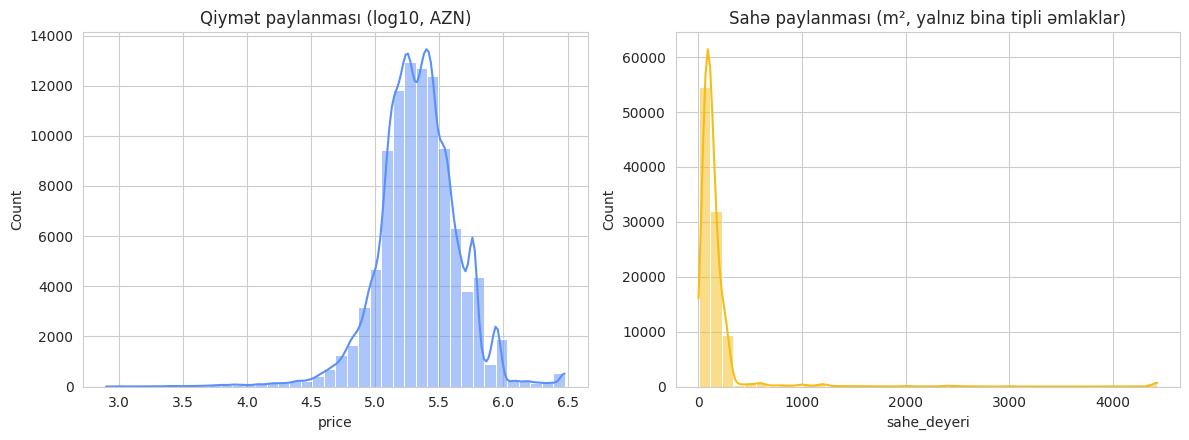

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(np.log10(df["price"]), bins=40, kde=True, ax=axes[0], color="#5B8FF9")
axes[0].set_title("Qiymət paylanması (log10, AZN)")
sns.histplot(df["sahe_deyeri"], bins=40, kde=True, ax=axes[1], color="#F6BD16")
axes[1].set_title("Sahə paylanması (m², yalnız bina tipli əmlaklar)")
plt.tight_layout()
plt.show()

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100504 entries, 0 to 100774
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   price                  100504 non-null  float64       
 1   location               100504 non-null  object        
 2   city                   100504 non-null  object        
 3   elan_tarixi            100504 non-null  datetime64[ns]
 4   vip                    100504 non-null  object        
 5   featured               100504 non-null  object        
 6   products_label         100504 non-null  object        
 7   estate_id              100504 non-null  object        
 8   owner_title            100504 non-null  object        
 9   lat                    100504 non-null  float64       
 10  lng                    100504 non-null  float64       
 11  views                  100504 non-null  float64       
 12  Kateqoriya             100504 non-null  object   

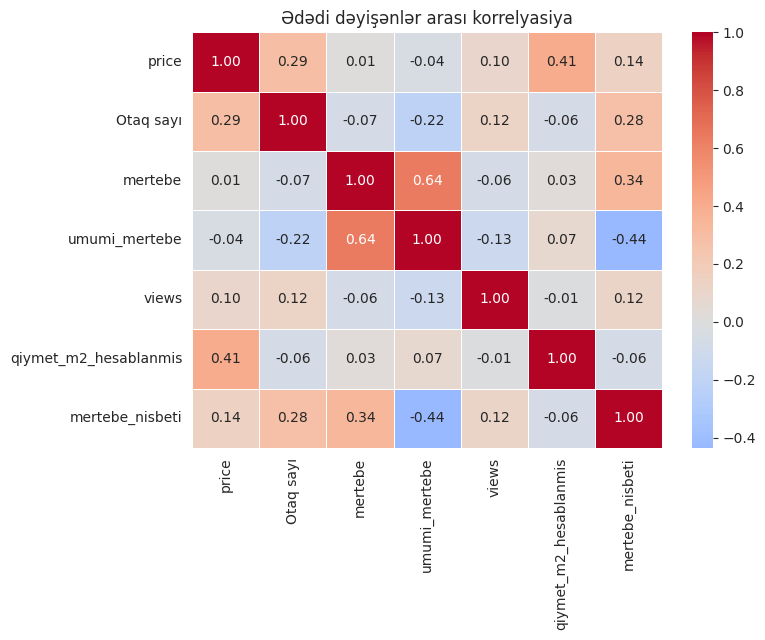

In [94]:
numeric_cols = ["price", "Otaq sayı", "mertebe", "umumi_mertebe", "views",
                "qiymet_m2_hesablanmis", "mertebe_nisbeti"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Ədədi dəyişənlər arası korrelyasiya")
plt.tight_layout()
plt.show()

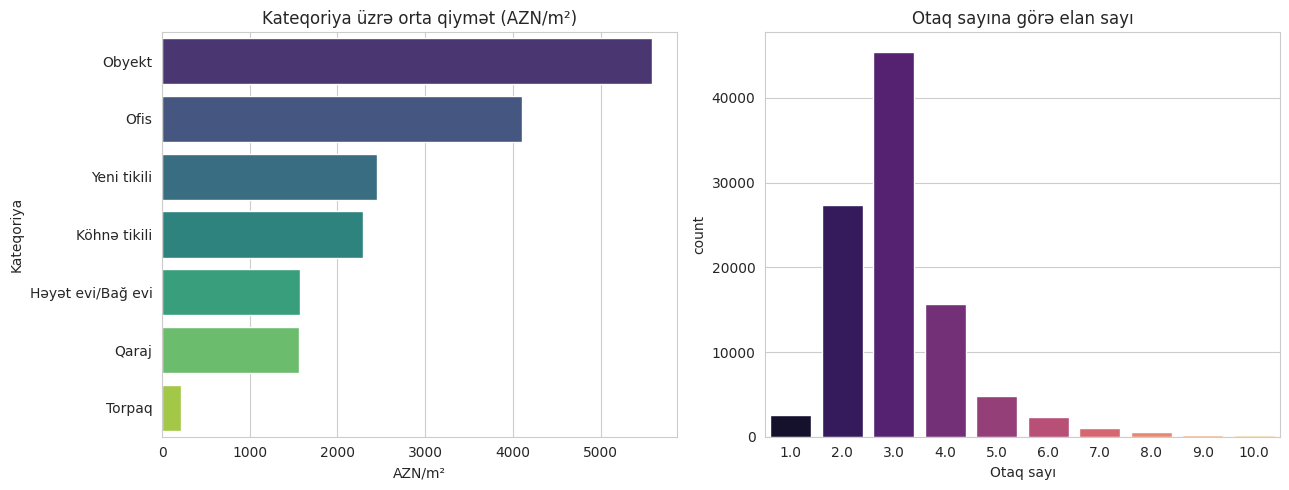

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

kat_qiymet = df.groupby("Kateqoriya")["qiymet_m2_hesablanmis"].mean().sort_values(ascending=False)
sns.barplot(x=kat_qiymet.values, y=kat_qiymet.index, ax=axes[0], palette="viridis")
axes[0].set_title("Kateqoriya üzrə orta qiymət (AZN/m²)")
axes[0].set_xlabel("AZN/m²")

sns.countplot(data=df, x="Otaq sayı", ax=axes[1],
              order=sorted(df["Otaq sayı"].dropna().unique())[:10], palette="magma")
axes[1].set_title("Otaq sayına görə elan sayı")
plt.tight_layout()
plt.show()

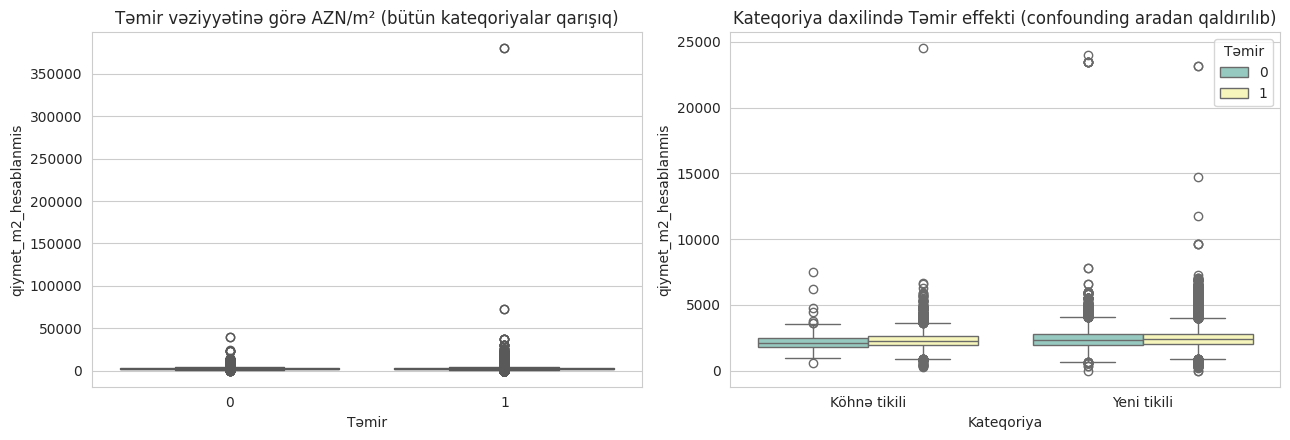

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="Təmir", y="qiymet_m2_hesablanmis",ax=axes[0], palette="Set2")
axes[0].set_title("Təmir vəziyyətinə görə AZN/m² (bütün kateqoriyalar qarışıq)")

sns.boxplot(data=df[(df["Kateqoriya"].isin(["Yeni tikili", "Köhnə tikili"]))],
            x="Kateqoriya", y="qiymet_m2_hesablanmis", hue="Təmir", ax=axes[1], palette="Set3")
axes[1].set_title("Kateqoriya daxilində Təmir effekti (confounding aradan qaldırılıb)")
plt.tight_layout()
plt.show()

Sağdakı qrafik **confounding effektini** göstərir: kateqoriyaları qarışdırıb baxdıqda Təmir=yoxdur daha bahalı görünür (çünki əksər "Yeni tikili" elanları hələ təmirsizdir, amma özü baha kateqoriyadır). Kateqoriya sabit saxlanıb müqayisə edildikdə isə real trend — təmirli mənzilin daha baha olması üzə çıxır.

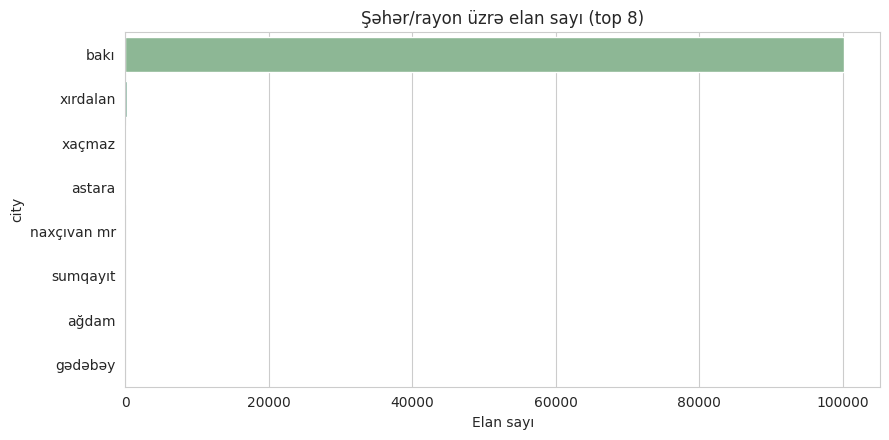

In [97]:
top_cities = df["city"].value_counts().head(8)
plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="crest")
plt.title("Şəhər/rayon üzrə elan sayı (top 8)")
plt.xlabel("Elan sayı")
plt.tight_layout()
plt.show()

## 6) Yazılı nəticə

Aşağıdakı 7 statistik nəticə əvvəlki versiyada ardıcıl print sətirləri kimi verilmişdi — rəqəmlər düzgün idi, amma şərhsiz. Burada hər ədəd üçün **niyə əhəmiyyətli olduğu** izah olunur, və Torpaq: nan AZN/m² xətası (yuxarıda 4-cü bölmədəki sıra düzəlişi ilə) aradan qaldırılıb — indi bütün kateqoriyalar üçün AZN/m² dəyəri mövcuddur.

In [98]:
top_kat = kat_qiymet.index[0]; top_kat_val = kat_qiymet.iloc[0]
low_kat = kat_qiymet.index[-1]; low_kat_val = kat_qiymet.iloc[-1]
corr_sahe_price = df[["sahe_deyeri", "price"]].corr().iloc[0, 1]
baki_payi = (df["city"] == "bakı").mean() * 100
teshvigat_payi = df["teshvigatli_elan"].mean() * 100
agent_payi = (df["owner_title"] == "vasitəçi (agent)").mean() * 100
en_cox_otaq = df["Otaq sayı"].mode()[0]

# Kateqoriya üzrə AZN/m² dəyərlərini yoxlayaq — heç biri artıq NaN olmamalıdır
assert kat_qiymet.notna().all(), "Kateqoriya üzrə AZN/m² hesablamasında hələ də NaN var"


**İnsight 1 — Qiymət diapazonu kateqoriyalar arasında kəskin fərqlənir.** Bu, tək model qurarkən Kateqoriyanın güclü bir prediktor (və ya ən azı stratifikasiya dəyişəni) olacağını göstərir — bütün əmlak növlərini tək bir qiymət modelində qarışdırmaq əhəmiyyətli xəta gətirər.

In [99]:
print(f"Ən baha AZN/m² kateqoriyası: {top_kat} ({top_kat_val:,.0f} AZN/m²)")
print(f"Ən ucuz AZN/m² kateqoriyası: {low_kat} ({low_kat_val:,.0f} AZN/m²)")


Ən baha AZN/m² kateqoriyası: Obyekt (5,593 AZN/m²)
Ən ucuz AZN/m² kateqoriyası: Torpaq (214 AZN/m²)


**İnsight 2 — Sahə ilə qiymət arasında gözlənildiyindən zəif korrelyasiya.** Adətən daha böyük əmlak daha bahalı olur, amma korrelyasiya əmsalının aşağı olması onu göstərir ki, Kateqoriya, location və təmir vəziyyəti kimi digər dəyişənlər qiymətə sahədən daha güclü təsir göstərir bu, sırf sahəyə əsaslanan sadə qiymətləndirmə modellərinin yetərsiz qalacağına işarədir.

In [100]:
print(f"Sahə (m²) və qiymət arasında korrelyasiya: {corr_sahe_price:.2f}")


Sahə (m²) və qiymət arasında korrelyasiya: 0.19


**İnsight 3 — Dataset demək olar ki, tamamilə Bakı üzrədir.** Bu, gözlənilən bir nəticədir (dataset elə Bakı əmlak bazarı üçün toplanıb), amma praktiki nəticəsi var: city sütunu region-səviyyəli müqayisə üçün faydasızdır (demək olar ki, sabitdir), gələcək analiz üçün location (məhəllə/rayon) sütunu daha informativ ola bilər.

In [101]:
print(f"Bakı payı bütün elanlarda: {baki_payi:.1f}%")


Bakı payı bütün elanlarda: 99.7%


**İnsight 4 — Elanların əksəriyyəti vasitəçi (agent) vasitəsilə yerləşdirilir, təşviqat isə azlıqdadır.** ~90% agent payı onu göstərir ki, owner_title sütunu 'birbaşa sahibdən' filtrasiyası üçün faydalı ola bilər (bəzi alıcılar məhz bunu axtarır). Aşağı təşviqat payı isə onu göstərir ki, teshvigatli_elan feature-ı balanssız (imbalanced) binar dəyişəndir — modelləşdirmə zamanı bu nəzərə alınmalıdır.

In [102]:
print(f"Təşviqatlı (vip/featured) elan payı: {teshvigat_payi:.1f}%")
print(f"Vasitəçi (agent) vasitəsilə qoyulan elan payı: {agent_payi:.1f}%")


Təşviqatlı (vip/featured) elan payı: 8.5%
Vasitəçi (agent) vasitəsilə qoyulan elan payı: 89.9%


**İnsight 5 — Ən çox rast gəlinən mənzil ölçüsü 3 otaqlıdır.** Bu, bazarın hansı seqmentə daha çox təmərküzləşdiyini göstərir (ailə tipli mənzillər) studiyalar/1 otaqlılar isə nisbətən az təmsil olunur, bu da onlar üçün proqnozun daha az nümunə üzərində qurulacağı deməkdir.

In [103]:
print(f"Ən çox rast gəlinən otaq sayı: {en_cox_otaq:.0f}")


Ən çox rast gəlinən otaq sayı: 3


## 7) Yekun

Bu notebook aşağıdakı prinsiplər əsasında qurulub və mentor rəyi əsasında yenidən işlənib:
- Hər null-doldurma qərarı **sütunun mənasına görə** (strukturlaşdırılmış yoxluq / aşağı-null ordinal / redundant identifikator / yüksək-null) qruplaşdırılıb, hər sütun üçün ayrıca, niyə məhz o üsulun seçildiyi izah olunub — mode bütün sütunlara mexaniki tətbiq olunmayıb (shop_name, owner_name, Binanın növü kimi silinəcək identifikator sütunlar artıq doldurulmur).
- Sütun silmə/parçalama qərarları faktiki yoxlamalarla (equality check-lərlə) sübut edilib, fərziyyə əsasında deyil.
- Outlier emalı kateqoriya-spesifik aparılıb ki, fərqli miqyaslı seqmentlər (Torpaq vs Mənzil) bir-birini təhrif etməsin.
- Feature engineering addımlarının hər biri üçün proqnozla əlaqəsi izah olunub (sadəcə 'necə' deyil, 'niyə mənalıdır').
- Sot→m² vahid çevrilməsinin sırası düzəldilib bu, əvvəlki versiyada Torpaq kateqoriyasının qiymet_m2_hesablanmis-də NaN qalmasına və yekun nəticələrdə **'Torpaq: nan AZN/m²'** xətasına səbəb olurdu.
- Yekun statistik nəticələr artıq təkcə rəqəm kimi deyil, hər biri üçün **niyə əhəmiyyətli olduğu** şərh edilərək təqdim olunub.
